### Explore Data matches

In [1]:
import psycopg2
import os
from pathlib import Path
from dotenv import load_dotenv
import logging
import pandas as pd
import numpy as np
from psycopg2 import sql
from psycopg2.extras import execute_values
import matplotlib.pyplot as plt

load_dotenv()

True

### Connect database

In [ ]:
db_host = os.getenv("DB_HOST", "localhost")

conn = psycopg2.connect(
    host="localhost",
    port=os.getenv("DB_PORT", "5432"),
    dbname=os.getenv("POSTGRES_DB", "db_etl"),
    user=os.getenv("POSTGRES_USER", "etl_user"),
    password=os.getenv("POSTGRES_PASSWORD", "etl_pass"),
)


### CATCH MATCHES

In [3]:
cursor = conn.cursor()
sql_query = sql.SQL("""SELECT
    *
FROM
    etl.matches
""")
cursor.execute(sql_query)
records = cursor.fetchall()
df = pd.DataFrame(records, columns=[desc[0] for desc in cursor.description])

print(df.head(10))


  season_code     league_name division  date_match        hometeam  \
0        1617  Premier League       E0  2016-08-13         Burnley   
1        1617  Premier League       E0  2016-08-13  Crystal Palace   
2        1617  Premier League       E0  2016-08-13         Everton   
3        1617  Premier League       E0  2016-08-13            Hull   
4        1617  Premier League       E0  2016-08-13        Man City   
5        1617  Premier League       E0  2016-08-13   Middlesbrough   
6        1617  Premier League       E0  2016-08-13     Southampton   
7        1617  Premier League       E0  2016-08-14         Arsenal   
8        1617  Premier League       E0  2016-08-14     Bournemouth   
9        1617  Premier League       E0  2016-08-15         Chelsea   

     awayteam  result_match  result_ht  league_id  home_cluster  ...  \
0     Swansea             2        1.0          2             1  ...   
1   West Brom             2        1.0          2             1  ...   
2   Tottenham

### Info of the data

In [4]:
print(df.shape[0])

10778


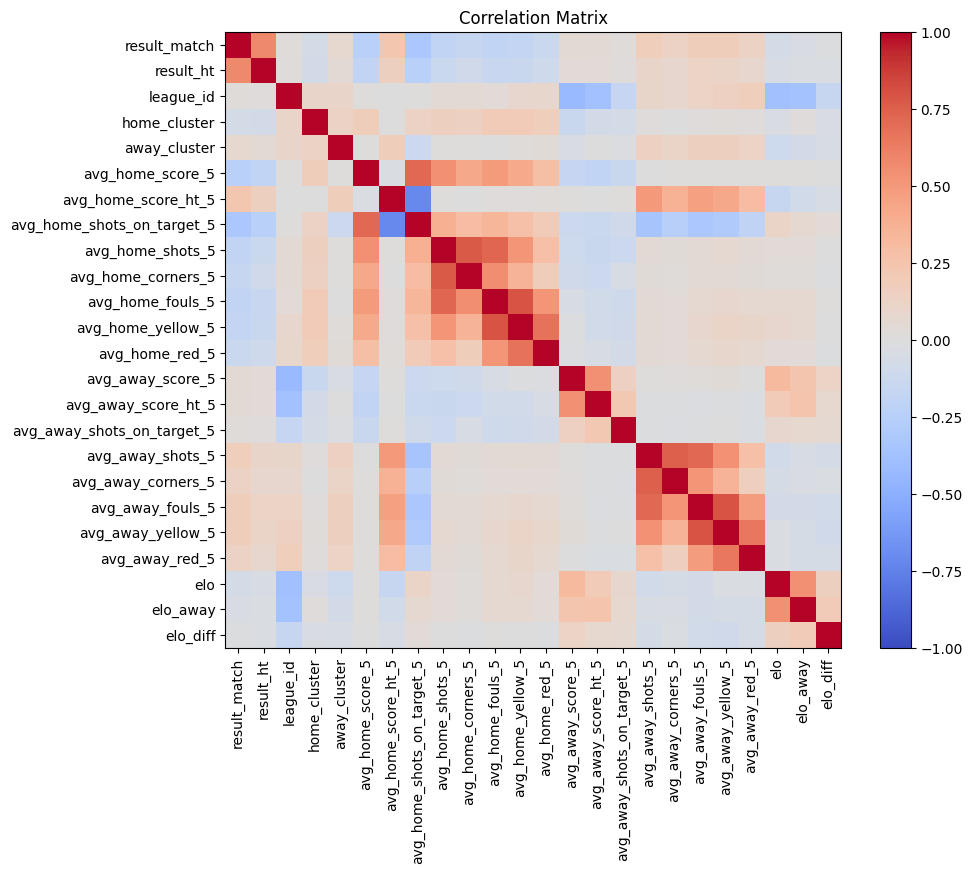

In [6]:
df = df.drop(columns=["season_code","league_name","division","date_match","hometeam","awayteam"])
corr = df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

## Grafics and outliers

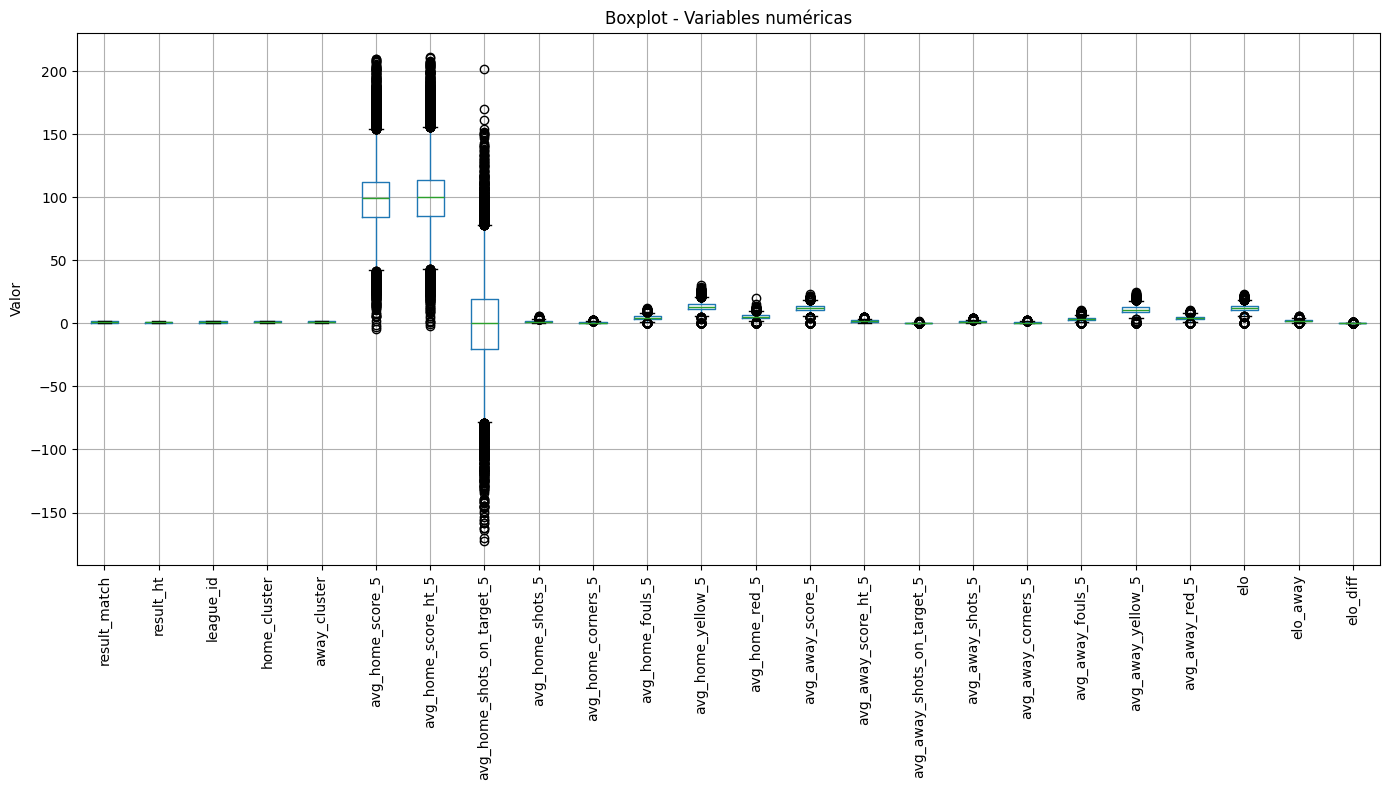

In [7]:

numeric_cols = df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(14, 8))
numeric_cols.boxplot(ax=ax, vert=True, rot=90)
ax.set_title('Boxplot - Variables numéricas')
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show()

Desviación estándar - avg_home_shots_on_target_5: 39.32594555940226
Mean - avg_home_shots_on_target_5: -0.6594637223974764


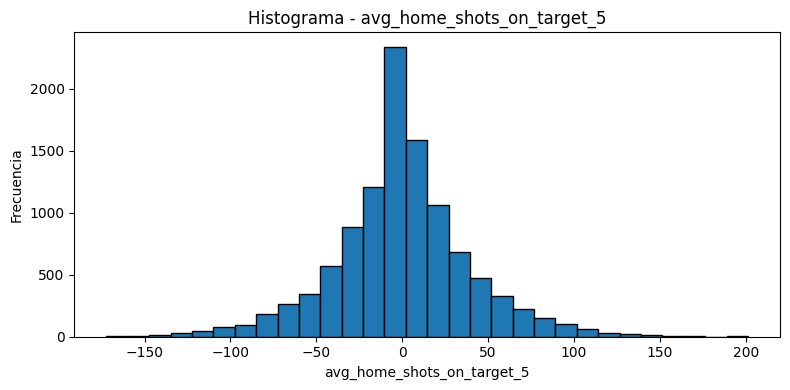

In [8]:
columns_to_check = ["avg_home_shots_on_target_5"]
for col in columns_to_check:
    print("=" * 40)
    print(f'Desviación estándar - {col}: {numeric_cols[col].std()}')
    print(f'Mean - {col}: {numeric_cols[col].mean()}')
    plt.figure(figsize=(8, 4))
    plt.hist(numeric_cols[col], bins=30, edgecolor='k')
    plt.title(f'Histograma - {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

In [16]:
print(numeric_cols[numeric_cols["avg_home_shots_on_target_5"] < 0].shape[0])
print(numeric_cols[numeric_cols["avg_home_score_5"] < 0].shape[0])
df_data = pd.read_csv("../src/data/final/matches_final.csv")
print(df_data[df_data["avg_home_shots_on_target_5"] < 0].shape[0])

5320
3
0


Desviación estándar - home_corners: 2.9304955451606607
Mean - home_corners: 5.403637375893106


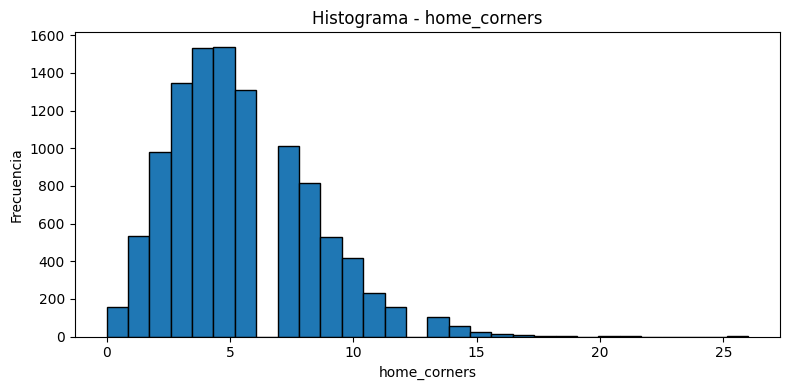

Desviación estándar - away_corners: 2.616160014232174
Mean - away_corners: 4.381182147165259


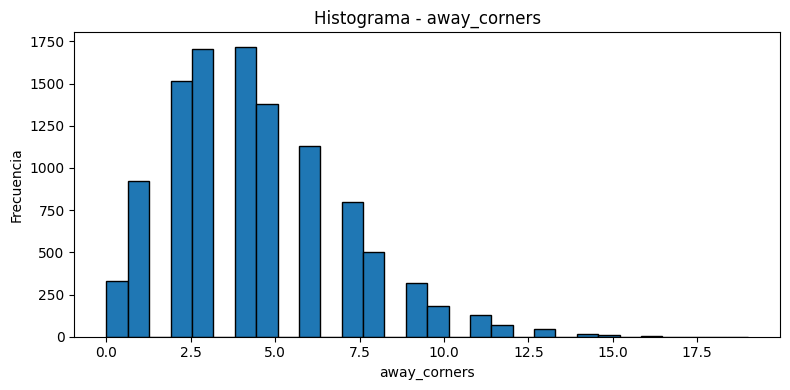

In [40]:
columns_to_check = ["home_corners", "away_corners"]
for col in columns_to_check:
    print("=" * 40)
    print(f'Desviación estándar - {col}: {numeric_cols[col].std()}')
    print(f'Mean - {col}: {numeric_cols[col].mean()}')
    plt.figure(figsize=(8, 4))
    plt.hist(numeric_cols[col], bins=30, edgecolor='k')
    plt.title(f'Histograma - {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

In [41]:
print(numeric_cols[numeric_cols["home_corners"] > 13].shape[0])
print(numeric_cols[numeric_cols["away_corners"] > 12].shape[0])

110
80
